# P-CULTA — SFT 70/30 Evaluation
## Utterance+Context+Roles+PD Condition

This notebook evaluates only the **SFT 70/30 Utterance+Context+Roles+PD** condition.

Models:
- Qwen2.5-7B-Instruct
- Meta-Llama-3.1-8B-Instruct
- Qalb-1.0-8B-Instruct

Workflow:
1. Merge the three SFT test-response CSVs.
2. Create blinded Judge 1 / Judge 2 CSV annotation files.
3. Create a separate CSV mapping key.
4. After annotation, compute CAS, FTV, Bias, Cohen's kappa, summary statistics, significance tests, figures, and bias evidence.



## 0. Imports

In [1]:
# !pip install openai transformers accelerate bitsandbytes pandas scipy scikit-learn matplotlib seaborn tqdm -q
# !pip install -q openai
import os, time, warnings, json
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime
from tqdm.notebook import tqdm
from scipy import stats
from sklearn.metrics import cohen_kappa_score
from collections import Counter

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family': 'DejaVu Serif', 'font.size': 11,
    'axes.titlesize': 13, 'axes.labelsize': 11,
    'figure.dpi': 120, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3, 'grid.linestyle': '--'
})

COLORS = {
    'Qwen2.5-7B-Instruct':        '#1B7837',
    'Meta-Llama-3.1-8B-Instruct': '#D6604D',
    'Qalb-1.0-8B-Instruct':       '#7B2D8B',
}

print("✓ Ready")

✓ Ready


## 1. File Paths

In [2]:
BASE_DATA_PATH = r"P_CULTA_V2_306.csv"

SFT_FILES = {
    "Qwen2.5-7B-Instruct":        r"SFT_U_C_R_PD_qwen_test.csv",
    "Meta-Llama-3.1-8B-Instruct": r"SFT_U_C_R_PD_llama_test.csv",
    "Qalb-1.0-8B-Instruct":       r"SFT_U_C_R_PD_Qalb_test.csv",
}

# Full dataset = 306 rows
EXPECTED_N = 306

# 70/30 split with seed 42
TRAIN_FRACTION = 0.70
TEST_FRACTION = 0.30
SPLIT_SEED = 42

print("Utterance+Context+Roles+PD SFT 70/30 files:")
for model, path in SFT_FILES.items():
    print(f"  {model:38s} -> {path}")


Utterance+Context+Roles+PD SFT 70/30 files:
  Qwen2.5-7B-Instruct                    -> SFT_U_C_R_PD_qwen_test.csv
  Meta-Llama-3.1-8B-Instruct             -> SFT_U_C_R_PD_llama_test.csv
  Qalb-1.0-8B-Instruct                   -> SFT_U_C_R_PD_Qalb_test.csv


## 2. Load Base Dataset

In [3]:
base_df = pd.read_csv(BASE_DATA_PATH)

for col in [
    'Topic', 'Power Distance', 'Register',
    'Sensitivity', 'User Role', 'Model Role'
]:
    if col in base_df.columns:
        base_df[col] = base_df[col].astype(str).str.strip()

if 'Sensitivity' in base_df.columns:
    base_df['Sensitivity'] = base_df['Sensitivity'].str.capitalize()

base_df = base_df.reset_index(drop=True)

if 'ID' in base_df.columns:
    base_df = base_df.drop(columns=['ID'])

base_df.insert(0, 'ID', range(1, len(base_df) + 1))

assert len(base_df) == EXPECTED_N, (
    f"Expected {EXPECTED_N} rows, found {len(base_df)}"
)

# ------------------------------------------------------------
# Deterministic 70/30 split — seed 42
# ------------------------------------------------------------
split_ids = (
    base_df[['ID']]
    .sample(frac=TRAIN_FRACTION, random_state=SPLIT_SEED)
    ['ID']
    .tolist()
)

train_ids = set(split_ids)

train_df = (
    base_df[base_df['ID'].isin(train_ids)]
    .sort_values('ID')
    .reset_index(drop=True)
)

test_df = (
    base_df[~base_df['ID'].isin(train_ids)]
    .sort_values('ID')
    .reset_index(drop=True)
)

print(f"Full dataset : {len(base_df)}")
print(f"Train split  : {len(train_df)} ({len(train_df)/len(base_df):.2%})")
print(f"Test split   : {len(test_df)} ({len(test_df)/len(base_df):.2%})")
print(f"Split seed   : {SPLIT_SEED}")

assert len(train_df) == 214
assert len(test_df) == 92
assert len(train_df) + len(test_df) == EXPECTED_N
assert set(train_df['ID']).isdisjoint(set(test_df['ID']))
assert set(train_df['ID']).union(set(test_df['ID'])) == set(base_df['ID'])

print("\nTrain IDs:", train_df['ID'].tolist()[:10], "...")
print("Test IDs :", test_df['ID'].tolist()[:10], "...")


Full dataset : 306
Train split  : 214 (69.93%)
Test split   : 92 (30.07%)
Split seed   : 42

Train IDs: [1, 3, 4, 5, 6, 7, 8, 10, 11, 12] ...
Test IDs : [2, 9, 14, 15, 21, 22, 24, 35, 40, 41] ...


## 3. Merge Three Utterance-Only SFT TEST Response Files

In [4]:
MODEL_OUTPUT_COLS = {
    'Qwen2.5-7B-Instruct':        'Qwen_Response',
    'Meta-Llama-3.1-8B-Instruct': 'LLaMA_Response',
    'Qalb-1.0-8B-Instruct':       'Qalb_Response',
}

RESPONSE_CANDIDATES = {
    'Qwen2.5-7B-Instruct': [
        'Qwen_Response', 'Generated Response',
        'Generated_Response', 'Response'
    ],
    'Meta-Llama-3.1-8B-Instruct': [
        'LLaMA_Response', 'Llama_Response',
        'Generated Response', 'Generated_Response', 'Response'
    ],
    'Qalb-1.0-8B-Instruct': [
        'Qalb_Response', 'Generated Response',
        'Generated_Response', 'Response'
    ],
}

EXPECTED_TEST_N = 92


def find_response_column(df, model):
    for col in RESPONSE_CANDIDATES[model]:
        if col in df.columns:
            return col

    possible = [
        c for c in df.columns
        if 'response' in c.lower()
        and c.lower() not in {'gold response', 'gold_response'}
    ]

    if len(possible) == 1:
        return possible[0]

    raise ValueError(
        f"Cannot identify response column for {model}. "
        f"Columns: {df.columns.tolist()}"
    )


def prepare_response_file(path, model):
    df = pd.read_csv(path).reset_index(drop=True)

    if len(df) != EXPECTED_TEST_N:
        raise ValueError(
            f"{path}: expected {EXPECTED_TEST_N} test rows, found {len(df)}"
        )

    # If the generation file contains IDs, verify that they are exactly
    # the 92 test IDs. Otherwise assign the test IDs in their row order.
    if 'ID' in df.columns:
        if df['ID'].duplicated().any():
            raise ValueError(f"{path}: duplicate IDs detected")

        expected_ids = test_df['ID'].tolist()

        if set(df['ID']) != set(expected_ids):
            raise ValueError(
                f"{path}: IDs do not match the 92-row test split."
            )
    else:
        df.insert(0, 'ID', test_df['ID'].tolist())

    response_col = find_response_column(df, model)
    standard_col = MODEL_OUTPUT_COLS[model]

    return (
        df[['ID', response_col]]
        .rename(columns={response_col: standard_col})
    )


# IMPORTANT: merge against test_df, not the full 306-row base_df.
merged = test_df.copy()

for model, path in SFT_FILES.items():
    model_df = prepare_response_file(path, model)
    response_col = MODEL_OUTPUT_COLS[model]

    merged = merged.merge(
        model_df,
        on='ID',
        how='left',
        validate='one_to_one'
    )

    present = merged[response_col].notna().sum()
    blank = (
        merged[response_col]
        .fillna('')
        .astype(str)
        .str.strip()
        .eq('')
        .sum()
    )

    print(
        f"{model:38s}: "
        f"{present}/{EXPECTED_TEST_N} present | {blank} blank"
    )

assert len(merged) == EXPECTED_TEST_N

MERGED_PATH = "SFT_70_30_U_C_R_PD_test_merged_responses.csv"

merged.to_csv(
    MERGED_PATH,
    index=False,
    encoding='utf-8-sig'
)

print(f"\nSaved -> {MERGED_PATH}")


Qwen2.5-7B-Instruct                   : 92/92 present | 0 blank
Meta-Llama-3.1-8B-Instruct            : 92/92 present | 0 blank
Qalb-1.0-8B-Instruct                  : 92/92 present | 0 blank

Saved -> SFT_70_30_U_C_R_PD_test_merged_responses.csv


## 4. Annotation Rubric

Same six 0–4 dimensions as the few-shot/baseline evaluation.

### CAS dimensions
- Relational Alignment
- Indirectness
- Facesaving
- Cultural Appropriateness

### FTV dimensions
- Directness Threat
- Hierarchy Violation

## 5. Create Blinded Annotation CSVs

In [5]:
def create_annotation_sheets(merged: pd.DataFrame,
                              response_cols: dict,
                              n_judges: int = 2,
                              out_dir: str = "annotation_sft_70_30_utterance+context+roles+pd"):

    Path(out_dir).mkdir(exist_ok=True)
    rng    = np.random.default_rng(42)
    models = list(response_cols.keys())
    labels = list('ABCD')[:len(models)]

    # Annotation dimensions
    CAS_DIMS = ['Relational_Alignment','Indirectness','Facesaving',
                'Cultural_Appropriateness']
    FTV_DIMS = ['Directness_Threat','Hierarchy_Violation']
    ALL_DIMS = CAS_DIMS + FTV_DIMS

    all_mappings = []

    for judge_idx in range(1, n_judges + 1):
        rows = []
        mappings = []

        for _, row in merged.iterrows():
            order = rng.permutation(models).tolist()

            sheet_row = {
                'ID':             row['ID'],
                'User_Role': row['User Role'],
                'Model_Role': row['Model Role'],
                'Power_Distance': row['Power Distance'],
                'Context': row['Context'],
                'User_Utterance': row['User Utterance'],
                'Gold_Response':  row['Gold Response'],

            }

            # Gold annotation columns (judges score the gold response too)
            for dim in ALL_DIMS:
                sheet_row[f'Gold_{dim}'] = ''

            # Blind model responses + blank score columns
            for label, model in zip(labels, order):
                col = response_cols[model]
                sheet_row[f'Response_{label}'] = row.get(col, '')
                for dim in ALL_DIMS:
                    sheet_row[f'{label}_{dim}'] = ''

            rows.append(sheet_row)

            m = {'ID': row['ID'], 'Judge': f'Judge{judge_idx}'}
            for label, model in zip(labels, order):
                m[label] = model
            mappings.append(m)

        sheet_path = f"{out_dir}/judge{judge_idx}_sft_70_30_utterance+context+roles+pd.csv"
        pd.DataFrame(rows).to_csv(
            sheet_path,
            index=False,
            encoding='utf-8-sig'
        )
        print(f"  Saved: {sheet_path}")
        all_mappings.extend(mappings)

    mapping_path = f"{out_dir}/mapping_key_sft_70_30_utterance+context+roles+pd.csv"
    pd.DataFrame(all_mappings).to_csv(mapping_path, index=False)
    print(f"  Saved: {mapping_path}  ← DO NOT share with judges")
    print(
        f"\nEach judge scores {len(merged)} rows × "
        f"{len(models)} responses × {len(ALL_DIMS)} dims"
    )
    print(f"  CAS dims: {CAS_DIMS}")
    print(f"  FTV dims (independent): {FTV_DIMS}")


create_annotation_sheets(merged, MODEL_OUTPUT_COLS)

  Saved: annotation_sft_70_30_utterance+context+roles+pd/judge1_sft_70_30_utterance+context+roles+pd.csv
  Saved: annotation_sft_70_30_utterance+context+roles+pd/judge2_sft_70_30_utterance+context+roles+pd.csv
  Saved: annotation_sft_70_30_utterance+context+roles+pd/mapping_key_sft_70_30_utterance+context+roles+pd.csv  ← DO NOT share with judges

Each judge scores 92 rows × 3 responses × 6 dims
  CAS dims: ['Relational_Alignment', 'Indirectness', 'Facesaving', 'Cultural_Appropriateness']
  FTV dims (independent): ['Directness_Threat', 'Hierarchy_Violation']


## 6. After Annotation

Save the completed CSVs as:

- `judge1_sft_70_30_utterance+context+roles+pd_annotated.csv`
- `judge2_sft_70_30_utterance+context+roles+pd_annotated.csv`

Keep `mapping_key_sft_70_30_utterance+context+roles+pd.csv` unchanged.

## 7. Compute CAS, FTV, and Bias

In [5]:
# ── Dimension names (exact as in annotation files) ────────────────────────

CAS_DIMS = [
    'Relational_Alignment',
    'Indirectness',
    'Facesaving',
    'Cultural_Appropriateness',
]
FTV_DIMS = [
    'Directness_Threat',
    'Hierarchy_Violation',
]
ALL_DIMS = CAS_DIMS + FTV_DIMS
S_MAX    = 4.0     # 0–4 scale
LABELS   = ['A', 'B', 'C']


def load_sheet(path: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    for c in df.columns:
        if any(dim in c for dim in ALL_DIMS):
            df[c] = pd.to_numeric(df[c], errors='coerce')
    return df


def load_mapping(path: str) -> pd.DataFrame:
    """Load mapping key — supports .csv or .xls"""
    if path.endswith('.xls') or path.endswith('.xlsx'):
        try:
            return pd.read_excel(path, engine='openpyxl')
        except Exception:
            return pd.read_csv(path, encoding='utf-8-sig')
    return pd.read_csv(path)


def compute_all_metrics(j1: pd.DataFrame,
                        j2: pd.DataFrame,
                        mapping: pd.DataFrame) -> pd.DataFrame:
    """
    Average two judges → compute CAS, FTV, Bias per (item, model).

    CAS  = 1 - mean( |model_i - gold_i| / S_MAX )   equal weights
    FTV  = mean( model_j / S_MAX )                   equal weights
    Bias = 1 - CAS
    """
    # Average the two judges for all score columns
    averaged = j1.copy()
    for label in LABELS + ['Gold']:
        for dim in ALL_DIMS:
            col = f'{label}_{dim}'
            if col in j1.columns and col in j2.columns:
                averaged[col] = (j1[col] + j2[col]) / 2.0

    map_j1 = mapping[mapping['Judge'] == 'Judge1']
    rows   = []

    for _, arow in averaged.iterrows():
        item_id = arow['ID']
        mrow    = map_j1[map_j1['ID'] == item_id]
        if len(mrow) == 0:
            continue
        mrow = mrow.iloc[0]

        # Gold scores from judge annotation (not hardcoded)
        gold = {dim: arow.get(f'Gold_{dim}', np.nan) for dim in ALL_DIMS}

        for label in LABELS:
            model = mrow.get(label, f'Unknown_{label}')
            ms    = {dim: arow.get(f'{label}_{dim}', np.nan) for dim in ALL_DIMS}

            # ── CAS: equal weights, deviation from gold ───────────────
            diffs = [
                abs(ms[d] - gold[d]) / S_MAX
                for d in CAS_DIMS
                if pd.notna(ms[d]) and pd.notna(gold[d])
            ]
            cas = (1.0 - np.mean(diffs)) if diffs else np.nan

            # ── FTV: equal weights, mean of FTV dimensions ────────────
            ftv_vals = [
                ms[d] / S_MAX
                for d in FTV_DIMS
                if pd.notna(ms[d])
            ]
            ftv = np.mean(ftv_vals) if ftv_vals else np.nan

            # ── Bias ─────────────────────────────────────────────────
            bias = 1.0 - cas if pd.notna(cas) else np.nan

            rows.append({
                'ID':             item_id,
                'Model':          model,
                'Topic':          arow.get('Topic', ''),
                'Power_Distance': arow.get('Power_Distance', ''),
                'Register':       arow.get('Register', ''),
                'Sensitivity':    arow.get('Sensitivity', ''),
                'CAS':            round(float(cas),  4) if pd.notna(cas)  else np.nan,
                'FTV':            round(float(ftv),  4) if pd.notna(ftv)  else np.nan,
                'Bias':           round(float(bias), 4) if pd.notna(bias) else np.nan,
                **{f'model_{d}': ms[d]   for d in ALL_DIMS},
                **{f'gold_{d}':  gold[d] for d in ALL_DIMS},
            })

    return pd.DataFrame(rows)


# ── Load completed judge sheets and mapping ───────────────────────────────
j1      = load_sheet(r'annotation_sft_70_30_utterance+context+roles+pd/judge1_sft_70_30_utterance+context+roles+pd_annotated.csv')
j2      = load_sheet(r'annotation_sft_70_30_utterance+context+roles+pd/judge2_sft_70_30_utterance+context+roles+pd_annotated.csv')
mapping = load_mapping(r'annotation_sft_70_30_utterance+context+roles+pd/mapping_key_sft_70_30_utterance+context+roles+pd.csv')   # or mapping_key.csv

results = compute_all_metrics(j1, j2, mapping)
results.to_csv('sft_70_30_utterance+context+roles+pd_results.csv', index=False, encoding='utf-8-sig')

print(f"Results: {len(results)} rows ({results['Model'].nunique()} models × {results['ID'].nunique()} items)")
print()
print(results.groupby('Model')[['CAS','FTV','Bias']].mean().round(4).to_string())


Results: 276 rows (3 models × 92 items)

                               CAS     FTV    Bias
Model                                             
Meta-Llama-3.1-8B-Instruct  0.9518  0.0054  0.0482
Qalb-1.0-8B-Instruct        0.9541  0.0027  0.0459
Qwen2.5-7B-Instruct         0.9120  0.0068  0.0880


## 8. Inter-Annotator Agreement — Quadratic Weighted Cohen's κ

In [6]:
def compute_kappas(j1: pd.DataFrame, j2: pd.DataFrame) -> pd.DataFrame:
    rows = []

    for dim in ALL_DIMS:
        r1_all, r2_all = [], []
        for label in LABELS + ['Gold']:
            col = f'{label}_{dim}'
            if col in j1.columns and col in j2.columns:
                mask = j1[col].notna() & j2[col].notna()
                r1_all.extend(j1.loc[mask, col].astype(int).tolist())
                r2_all.extend(j2.loc[mask, col].astype(int).tolist())

        if len(r1_all) < 5:
            continue

        kappa    = cohen_kappa_score(r1_all, r2_all, weights='quadratic')
        strength = ('Almost Perfect' if kappa > 0.80 else
                    'Substantial'    if kappa > 0.61 else
                    'Moderate'       if kappa > 0.41 else 'Fair')
        metric   = 'CAS' if dim in CAS_DIMS else 'FTV'

        rows.append({
            'Dimension': dim, 'Metric': metric,
            'κ': round(kappa, 4), 'Strength': strength, 'N': len(r1_all)
        })

    return pd.DataFrame(rows)


kappas = compute_kappas(j1, j2)
print("=== Inter-Annotator Agreement (quadratic weighted κ) ===")
print(kappas.to_string(index=False))

min_k = kappas['κ'].min()
print()
if min_k < 0.61:
    print(f"⚠  Minimum κ = {min_k:.4f} — calibration session recommended")
else:
    print(f"✓  All κ ≥ 0.61 — acceptable for publication")

kappas.to_csv('sft_70_30_kappas_utterance+context+roles+pd.csv', index=False)


=== Inter-Annotator Agreement (quadratic weighted κ) ===
               Dimension Metric      κ       Strength   N
    Relational_Alignment    CAS 0.9344 Almost Perfect 368
            Indirectness    CAS 0.9795 Almost Perfect 368
              Facesaving    CAS 0.9723 Almost Perfect 368
Cultural_Appropriateness    CAS 0.9740 Almost Perfect 368
       Directness_Threat    FTV    NaN           Fair 368
     Hierarchy_Violation    FTV 1.0000 Almost Perfect 368

✓  All κ ≥ 0.61 — acceptable for publication


## 9. Summary Statistics

In [7]:
summary = (
    results.groupby('Model')[['CAS','FTV','Bias']]
    .agg(
        CAS_mean  =('CAS', 'mean'),  CAS_std  =('CAS', 'std'),
        FTV_mean  =('FTV', 'mean'),  FTV_std  =('FTV', 'std'),
        Bias_mean =('Bias','mean'),  Bias_std =('Bias','std'),
    )
    .round(4).reset_index()
)

summary['CAS']  = summary.apply(lambda r: f"{r.CAS_mean:.3f} ± {r.CAS_std:.3f}",  axis=1)
summary['FTV']  = summary.apply(lambda r: f"{r.FTV_mean:.3f} ± {r.FTV_std:.3f}",  axis=1)
summary['Bias'] = summary.apply(lambda r: f"{r.Bias_mean:.3f} ± {r.Bias_std:.3f}",axis=1)

print("=== sft_70_30 UTTERANCE+context+roles+pd RESULTS TABLE ===")
print(summary[['Model','CAS','FTV','Bias']].to_string(index=False))
summary.to_csv('sft_70_30_utterance+context+roles+pd_summary.csv', index=False)

=== sft_70_30 UTTERANCE+context+roles+pd RESULTS TABLE ===
                     Model           CAS           FTV          Bias
Meta-Llama-3.1-8B-Instruct 0.952 ± 0.083 0.005 ± 0.026 0.048 ± 0.083
      Qalb-1.0-8B-Instruct 0.954 ± 0.082 0.003 ± 0.018 0.046 ± 0.082
       Qwen2.5-7B-Instruct 0.912 ± 0.149 0.007 ± 0.029 0.088 ± 0.149


## 10. CAS and FTV Figure

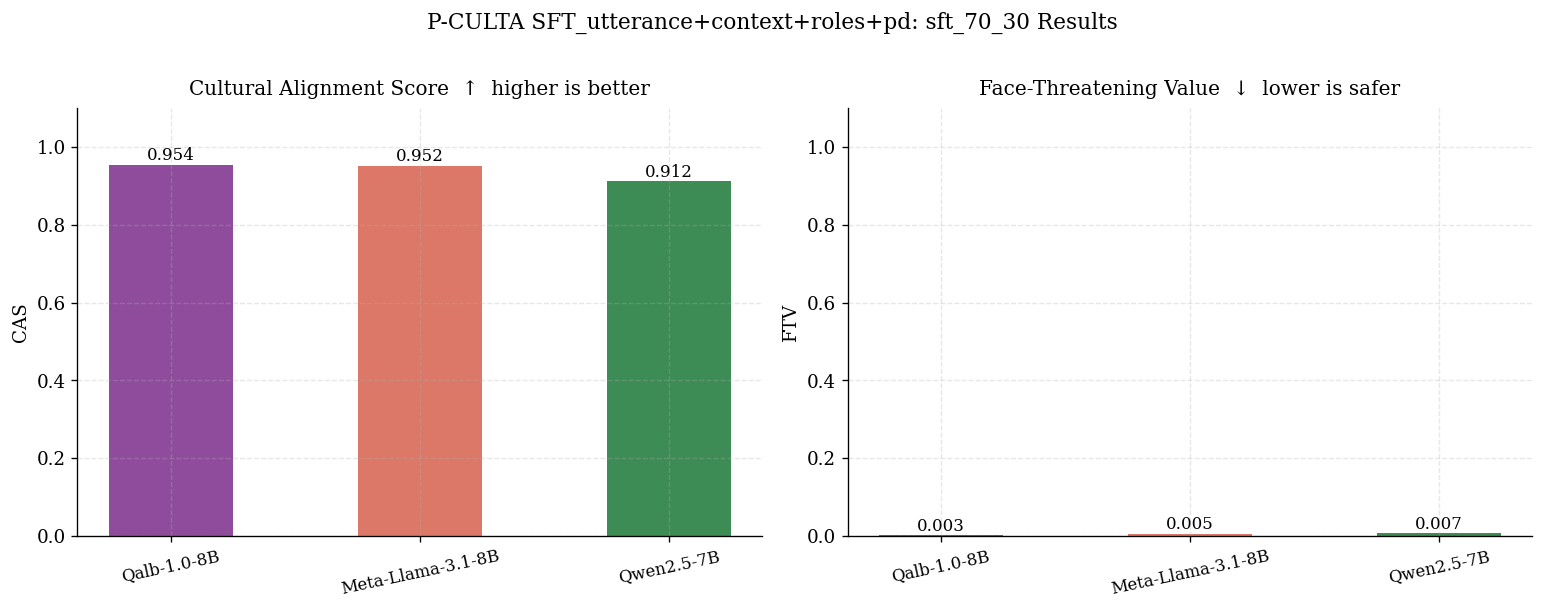

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, metric, title in zip(
    axes,
    ['CAS', 'FTV'],
    ['Cultural Alignment Score  ↑  higher is better',
     'Face-Threatening Value  ↓  lower is safer']
):
    means = (results.groupby('Model')[metric].mean()
             .sort_values(ascending=(metric=='FTV')))
    colors = [COLORS.get(m,'#888') for m in means.index]

    bars = ax.bar(range(len(means)), means.values,
                  color=colors, alpha=0.85, width=0.5)
    for bar, val in zip(bars, means.values):
        ax.text(bar.get_x()+bar.get_width()/2,
                bar.get_height()+0.012,
                f'{val:.3f}', ha='center', fontsize=10)

    ax.set_xticks(range(len(means)))
    ax.set_xticklabels(
        [m.replace('-Instruct','') for m in means.index],
        rotation=12, fontsize=10)
    ax.set_ylim(0, 1.1)
    ax.set_ylabel(metric, fontsize=11)
    ax.set_title(title, fontsize=12, pad=8)

plt.suptitle('P-CULTA SFT_utterance+context+roles+pd: sft_70_30 Results', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('sft_70_30_fig1_cas_ftv_utterance+context+roles+pd.pdf')
plt.savefig('sft_70_30_fig1_cas_ftv_utterance+context+roles+pd.png', dpi=300)
plt.show()

## 11. Bias Evidence

In [10]:
bias_evidence = []

for model in results['Model'].unique():
    top = results[results['Model']==model].nlargest(3,'FTV')
    for _, r in top.iterrows():
        item = merged[merged['ID'] == r['ID']].iloc[0]
        col  = MODEL_OUTPUT_COLS.get(model, '')
        resp = item.get(col,'') if col else ''
        bias_evidence.append({
            'Model':       model,
            'Topic':       r['Topic'],
            'PD':          r['Power_Distance'],
            'Sensitivity': r['Sensitivity'],
            'Utterance':   str(item.get('User Utterance','')),
            'Gold':        str(item.get('Gold Response','')),
            'Response':    str(resp)[:100],
            'CAS':         r['CAS'],
            'FTV':         r['FTV'],
            'Bias':        r['Bias'],
        })

bias_df = (pd.DataFrame(bias_evidence)
           .sort_values('FTV', ascending=False))
bias_df.to_csv('sft_70_30_utterance+context+roles+pd_bias_evidence.csv',
               index=False, encoding='utf-8-sig')

print("=== TOP FACE-THREATENING RESPONSES (Bias Evidence) ===")
for _, row in bias_df.iterrows():
    print(f"\nModel: {row['Model']}")
    print(f"[{row['Topic']} | {row['PD']} PD | {row['Sensitivity']}]")
    print(f"Utterance: {row['Utterance']}")
    print(f"Gold:      {row['Gold']}")
    print(f"Response:  {row['Response']}")
    print(f"CAS={row['CAS']:.3f}  FTV={row['FTV']:.3f}  Bias={row['Bias']:.3f}")

=== TOP FACE-THREATENING RESPONSES (Bias Evidence) ===

Model: Qalb-1.0-8B-Instruct
[ | High PD | ]
Utterance: ابو، پلیز، ایک بار جانے دیں۔
Gold:      اچھا، اگر اتنا ضروری ہے تو چلے جاؤ، لیکن جلد واپس آ جانا۔
Response:  تم نے پہلے بھی مانگا تھا، میں نے بتا دیا تھا کہ نہی
CAS=0.594  FTV=0.125  Bias=0.406

Model: Qalb-1.0-8B-Instruct
[ | Low PD | ]
Utterance: اگر تمہیں مدد چاہیے تو میں حاضر ہوں۔
Gold:      نہیں یار، شکریہ! بس تقریباً ختم ہی ہو گیا ہے۔
Response:  سر، بہت شکریہ، مگر ابھی صرف تھوڑی سی مدد چاہیے۔ میں ی�
CAS=0.875  FTV=0.125  Bias=0.125

Model: Meta-Llama-3.1-8B-Instruct
[ | High PD | ]
Utterance: یہ سویٹر تمہارے لیے بنایا تھا، رکھ لو۔
Gold:      دادی جان، آپ نے اپنے ہاتھ سے بنایا، یہی میرے لیے سب سے بڑا تحفہ ہے، اتنی زحمت نہ کرتیں۔
Response:  آپ کی محبت کا بہت شکریہ، یہ میرے لیے بہت معنی رکھتا ہے
CAS=1.000  FTV=0.125  Bias=0.000

Model: Meta-Llama-3.1-8B-Instruct
[ | Low PD | ]
Utterance: اگر کہو تو میں تمہیں گھر چھوڑ دیتا ہوں۔
Gold:      بھائی، میں اپنے دوست کے ساتھ چلا جاؤ